In [1]:
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import os
os.environ['ESMFMKFILE'] = 'C:/Users/eving/AppData/Local/miniconda3/envs/evalprecextremes/Library/lib/esmf.mk'
import xesmf as xe
import numpy as np
np.float_ = np.float64
from metpy.units import units
import matplotlib.colors as mcolors
from clisops.core import subset
from metpy.plots import ctables
import matplotlib.ticker as ticker
import cmaps
import geopandas as gpd
import seaborn as sns
from shapely.geometry import Point, Polygon
import rioxarray
from math import nan
from scipy import stats
import statsmodels.api as sm
from collections import OrderedDict
import sys

In [2]:
# Original Projection
projorig_name  = "PlateCarree"
projorig_dict  = dict()
projorig       = ccrs.__dict__[projorig_name].__call__(**projorig_dict)

# Input data
# EURO-CORDEX RCMs
RCMs = OrderedDict() 
RCMs['CNRM-ALADIN64E1'] = {'projplot' : 'LambertConformal',
                           'projplot_dict' : dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45), false_easting = 2925000., false_northing = 2925000.)}
RCMs['HCLIM43-ALADIN'] = {'projplot' : 'LambertConformal',
                          'projplot_dict' : dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45), false_easting = 2925000., false_northing = 2925000.)}
RCMs['ALARO1-SFX'] = {'projplot' : 'LambertConformal',
                      'projplot_dict' : dict(central_longitude=9.9, central_latitude=49.0, standard_parallels=(33,45), false_easting = 3012.5, false_northing = 3012.5)}
RCMs['RACMO23E']   = {'projplot' : 'RotatedPole',
                      'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['ICON-CLM-202407-1-1'] = {'projplot' : 'RotatedPole',
                               'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['CCLM6-0-1'] = {'projplot' : 'RotatedPole',
                     'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['RegCM5-0'] = {'projplot' : 'RotatedPole',
                    'projplot_dict' : dict(pole_longitude=198, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['REMO2020-2-2'] = {'projplot' : 'RotatedPole',
                        'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['WRF451Q'] = {'projplot' : 'RotatedPole',
                   'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}

# Graphic projection
projplot       = "LambertConformal"
projplot_dict  = dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45))
projplot       = ccrs.__dict__[projplot].__call__(**projplot_dict)

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
C:\Users\eving\AppData\Local\Temp\ipykernel_4900\2958102775.py:74: RuntimeWarning: divide by zero encountered in divide
  Z = (ZMOD / ZOBS - 1) * 100


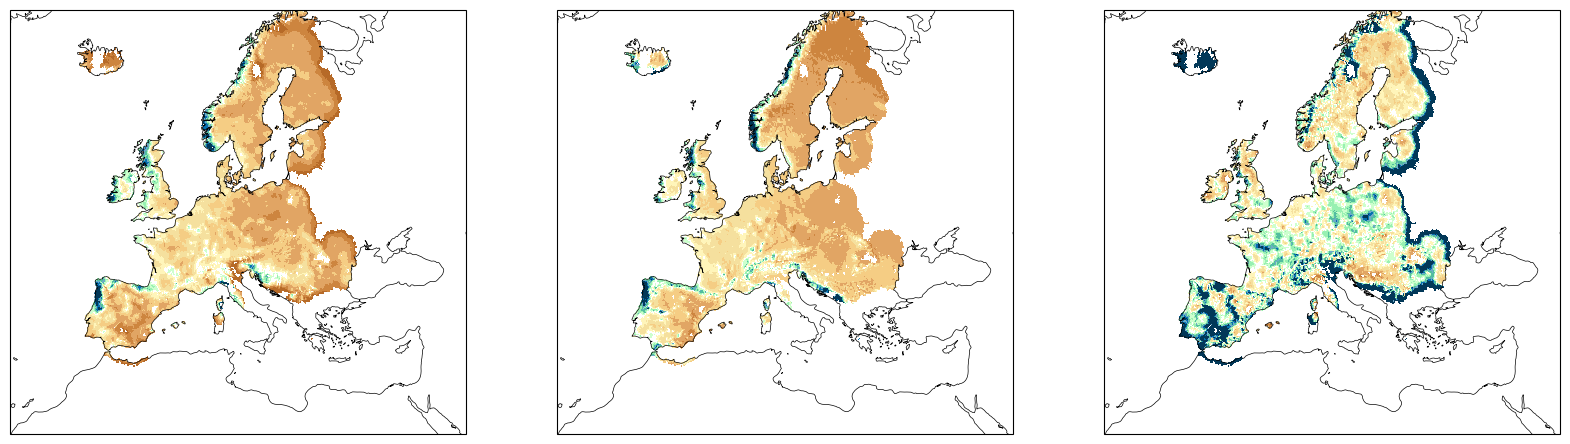

In [31]:
folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
folder_model = 'D:/EUROCORDEX_extremes/DATA/SIM/'

name_models = ['ERA5_ALARO1-SFX','ERA5_CCLM6-0-1','ERA5_CNRM-ALADIN64E1',
            'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
            'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']
label_models = ['ALARO1-SFX','CCLM6-0-1','ALADIN64E1',
            'HCLIM43','ICON-CLM','RACMO23E',
            'RegCM5-0','REMO2020','WRF451Q']
obs = 'OBS_EURADCLIM_011EUi_2013-2022'

# reference file for the regridding
fMod = 'ERA5_WRF451Q1980-2020_SON_all_24h_perc.nc'
dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")
rlat_424_412 = dsMod.rlat.values
rlon_424_412 = dsMod.rlon.values

agg = '1'
season = 'DJF'

# load mask
mask = np.load(f'D:/EUROCORDEX_extremes/DATA/OBS/mask_eurad_{season}.npy')

quantile = 'perc_99.00'

# Initialiser la figure et les axes
fig, axes = plt.subplots(ncols=3,figsize=(20, 7),subplot_kw={'projection': projplot})

fObs = f'{obs}_{season}_all_{agg}h_perc.nc'
dsObs = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
dsObs_cor = dsObs.cf.add_bounds(["lon","lat"])
if(agg != '1'):
    dsObs_cor = dsObs_cor.where(dsObs_cor != 0)

model = name_models[2]
      
# reference file for the regridding
fMod = f'{model}1980-2020_{season}_all_{agg}h_perc.nc'

# aladin simulation to be regridded
dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")

if model == 'ERA5_RegCM5-0':
    dsMod = dsMod.assign_coords(rlat=rlat_424_412, rlon=rlon_424_412)

dsMod = dsMod.cf.add_bounds(["lon","lat"])

# regrid obs
regridder = xe.Regridder(
    dsMod, dsObs_cor, "conservative", unmapped_to_nan=True, ignore_degenerate=True
)
dsMod_regrid = regridder(dsMod, keep_attrs=True)

X = dsObs_cor.lon
Y = dsObs_cor.lat
ZOBS = dsObs_cor[quantile]
ZMOD = dsMod_regrid[quantile]

# obs
ZOBS = np.where(mask, np.nan, ZOBS) # Set values outside the range to NaN
plot = axes[0].pcolormesh(X, Y, ZOBS, cmap=cmaps.precip_diff_12lev, vmin=0, vmax=5,
                transform=projorig, zorder=1)
axes[0].set_extent((-15, 38, 25, 70))  # France zoom
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.5)        # Draw coastlines

# model
ZMOD = np.where(mask, np.nan, ZMOD) # Set values outside the range to NaN
plot = axes[1].pcolormesh(X, Y, ZMOD, cmap=cmaps.precip_diff_12lev, vmin=0, vmax=5,
                transform=projorig, zorder=1)
axes[1].set_extent((-15, 38, 25, 70))  # France zoom
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.5)

# diff
Z = (ZMOD / ZOBS - 1) * 100
Z = np.where(mask, np.nan, Z) # Set values outside the range to NaN
plot = axes[2].pcolormesh(X, Y, Z, cmap=cmaps.precip_diff_12lev, vmin=-65, vmax=65,
                transform=projorig, zorder=1)
axes[2].set_extent((-15, 38, 25, 70))  # France zoom
axes[2].add_feature(cfeature.COASTLINE, linewidth=0.5)


C:\Users\eving\AppData\Local\Temp\ipykernel_4900\2403195236.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_factor, labels=labels)


(-100.0, 100.0)

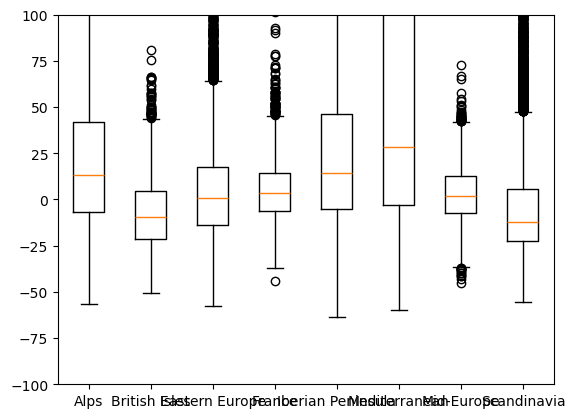

In [32]:
# mask the different regions
gdf = gpd.read_file("regions.geojson")

Z2CLIP = dsObs_cor[quantile]
Z2CLIP.values = Z
Z2CLIP.rio.write_crs("EPSG:4326", inplace=True)

# reproject the GeoDataFrame to match the CRS of the raster data
gdf_proj = gdf.to_crs(Z2CLIP.rio.crs)

# 1. Initialize an empty list
df_list = []

for ic, region in gdf.iterrows():

    # prepare data for boxplot
    Zclip = Z2CLIP.rio.clip([region['geometry']], crs=gdf_proj.crs)
    zvec = Zclip.values.flatten()
    zvec = zvec[~np.isnan(zvec)]
    nzvec = len(zvec)

    # Simulated dataframe generation
    small_df = pd.DataFrame({"region": [region['names']]*nzvec,
                            "value": zvec})
    df_list.append(small_df)

# 3. Concatenate everything once after the loop
df_plot = pd.concat(df_list, ignore_index=True)

# 2. Group the data and extract the values into a list
grouped = df_plot.groupby('region')['value']
data_by_factor = [group for name, group in grouped]
labels = [name for name, group in grouped]

# 3. Create the boxplot
fig, ax = plt.subplots()
ax.boxplot(data_by_factor, labels=labels)
ax.set_ylim(-100, 100) 